In [1]:
import os
import time

import pandas as pd
import numpy as np
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import preprocess as pp 
from scLEMBAS.model.train import TrainSC
from scLEMBAS.model.scl import SignalingModel

from Tahoe_utils import Tahoe100M_split

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nobackup/


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [2]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
mod_seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'

device = "cuda" if torch.cuda.is_available() else "cpu"

Load data:

In [3]:
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', author + '_sn_ppis.csv'), 
                     index_col = 0)
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

tf_adata = io.read_tfad(os.path.join(data_path, 'processed', author + '_consensus_tf_activity.h5ad'))
adata = sc.read_h5ad(os.path.join(data_path, 'processed', author + '_expr_in.h5ad'))
expr = adata.to_df().copy()

# basic formatting checks
if not np.all(tf_adata.var_names == sorted(tf_adata.var_names)):
    raise ValueError('Ensure TF adata features are sorted on input')
    
if not np.all(adata.obs_names == tf_adata.obs_names):
    raise ValueError('Ensure gene expression and TF activity sample features are orderd the same')
    
if len(set(tf_adata.obs.drug)) != len(tf_adata.obs.drug.cat.categories):
    raise ValueError('Make sure only present perturbations are in the categorical columns')
    
if len(set(tf_adata.obs.cell_line)) != len(tf_adata.obs.cell_line.cat.categories):
    raise ValueError('Make sure only present cell lines are in the categorical columns')

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Train/test split:

In [4]:
train_split, test_split = Tahoe100M_split(tf_adata,
                                          train_frac = 0.9, 
                                          min_drug_frac = 0.7, 
                                          min_cell_line_frac = 0.7, 
                                          exclude_control = False, 
                                          max_attempts = 1000, 
                                          seed = seed)

train_cells = train_split['barcodes']
test_cells = test_split['barcodes']

cell_line_counts = pd.DataFrame({
    'train': train_split['cell_line_counts'],
    'test': test_split['cell_line_counts']
}).sort_values(by = 'train', ascending = True)

drug_counts = pd.DataFrame({
    'train': train_split['drug_counts'],
    'test': test_split['drug_counts']
}).sort_values(by = 'train', ascending = True)



In [5]:
cell_line_counts

,train,test
cell_line,,
CVCL_0371,23,6
CVCL_0546,24,5
CVCL_1056,24,5
CVCL_0480,26,3
CVCL_1550,26,3
CVCL_0459,27,2
CVCL_1285,27,2
CVCL_0023,28,1
CVCL_0399,28,1


In [6]:
drug_counts

,train,test
drug,,
Neratinib (maleate),8,2
Almonertinib (mesylate),8,2
Tofacitinib (citrate),8,2
Rucaparib (phosphate),8,2
Retinoic acid,8,2
Rapamycin,8,2
Norepinephrine (hydrochloride),8,2
Filgotinib,8,2
Tofacitinib,9,1


In [7]:
train_adata = tf_adata[train_cells, :].copy()
train_adata.obs.condition.value_counts().unique()

array([2099])

In [8]:
train_adata.obs.drug.value_counts().unique()

array([20990, 18891, 16792])

In [9]:
train_adata.obs.cell_line.value_counts().unique()

array([58772, 56673, 54574, 50376, 48277])

**Note: As mentioned in Notebook 00A, when splitting the data into train-test splits, conditions will remain balanced, but drug/cell lines will not be completely balanced (due to OOD, cannot ensure the drug and cell line split is the same as the condition split).** 

# Hyper-parameters:

In [10]:
def generate_lr_params(n_epochs, 
                       max_lr, 
                       lr_scaling_factor=10, 
                       lr_decay=0.75,
                       n_restarts = 4,
                       n_discriminator_train=5, 
                       n_adversarial_start = 0,
                       role='scl'):
    """
    Generate LR scheduler params for WarmupCosineAnnealingWarmRestarts
    that ensures discriminator and generator follow the same curve in real (epoch) time.

    Parameters:
        - n_epochs: total training epochs
        - max_lr: peak learning rate
        - lr_scaling_factor: factor to determine min LR
        - lr_decay: gamma decay per restart
        - n_restarts: desired number of cosine peaks (n_restarts)
        - n_adversarial_start: epoch when adversarial training begins
        - n_discriminator_train: frequency of discriminator training relative to generator
        - role: 'scl' or discriminator' or 'generator'

    Returns:
        Dict of scheduler parameters
    """
    
    
    
    total_active_epochs = n_epochs
    n_discriminator_train_ = 1
    if role in ['discriminator', 'generator']:
        total_active_epochs = n_epochs - n_adversarial_start
        if role == 'generator':
            n_discriminator_train_ = n_discriminator_train
            
#     n_restarts = 4 if total_active_epochs // n_discriminator_train_ > 500 else 2


    T_0 = max(1, (total_active_epochs // n_discriminator_train_) // n_restarts)
    warmup_epochs = max(1, (total_active_epochs // n_discriminator_train_) // 10)

#     if reset_state:
#         if total_active_epochs // n_discriminator_train_ > 400:
#             n_optimizer_resets = 2
#         elif total_active_epochs // n_discriminator_train_ < 100:
#             n_optimizer_resets = 0
#         else:
#             n_optimizer_resets = 1
#     else:
#         n_optimizer_resets = 0
        
    if warmup_epochs >= T_0:
        warmup_epochs = 0

    return {
        'max_epochs': n_epochs,
        'maximum_learning_rate': max_lr,
        'minimum_learning_rate': max_lr / lr_scaling_factor,
        'lr_restart_epoch': T_0,  
        'n_optimizer_resets': 0,  # no longer used
        'lr_decay': lr_decay,
        'lr_restart_factor': 1,
        'warmup_epochs': warmup_epochs
    }

In [11]:
projection_amplitude_in = 10
projection_amplitude_out = 1

bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor': 50, 
                 'tolerance': 1e-5, 
                 'leak': 1e-2}

spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 5, 
                          'subset_n_spectral': 5}
target_spectral_radius = 0.9

noise_params = {
    'network_noise_scale': 0.01, 
    'min_network_noise': 0.0025, 
    'gradient_noise_scale': 1e-9, 
    'include_gradient_noise_vae': True, 
    'include_gradient_noise_embedding': True, 
    'constant_gradient_noise': True
    
}

In [12]:
loss_scaler = 100
prediction_loss_fn = torch.nn.MSELoss(reduction='mean')
per_condition_loss = False # TODO: check this


batch_params = {
    'train_batch_size': int(512*8), 
    'test_batch_size': int(512*8), 
    'validation_batch_size': np.nan
}
max_epochs = 600


max_lr = 0.001
lr_scaling_factor = 10
lr_decay = 0.75
n_restarts = 4
lr_params = generate_lr_params(n_epochs = max_epochs, 
                               max_lr = max_lr, 
                               lr_scaling_factor = lr_scaling_factor, 
                               lr_decay = lr_decay,
                               n_restarts = n_restarts,
                               n_adversarial_start = np.nan, 
                               n_discriminator_train = np.nan, 
                               role = 'scl')

# reset_state = False # DEPRECATED
# initialize_fc = True # DEPRECATED

In [13]:
bionet_params['cat_max_norm'] = 100
regularization_params = {
    'input_lambda_L2': 0, # irrelevant because setting the requires grad to False
    
    'bn_weights_lambda_L2': 1e-7,
    'moa_lambda_L1': 1e2,
    'uniform_lambda_L2': 1e-7, 
    'uniform_min': -1/projection_amplitude_out,
    'uniform_max': 1/projection_amplitude_out,
    'adj_scaling_KL': 0,  # using uniform/bn_weights already
    'adj_prior_mu': 0, # irrelevant because adj_scaling_KL is 0
    'adj_prior_sigma': 0.2, # irrelevant because adj_scaling_KL is 0
    
    'output_weights_lambda_L2': 1e-7,
    'output_bias_lambda_L2': 1e-7,
    
    'spectral_loss_factor': 1e-6,
    
    
    'global_bias_lambda_L2': 0, # using KL divergence instead
    'global_bias_lambda_L1': 0, # using KL divergence instead
    'cat_bias_lambda_L2': 0, # using cat max norm
    'cat_bias_lambda_L1': 0, # using cat max norm
    'cat_bias_orthogonality_scaler': 0
}

In [14]:
training_params = {
    **lr_params, 
    **batch_params, 
    **regularization_params, 
    **spectral_radius_params,
    **noise_params
}

training_params['prediction_loss_fn_scaler'] = loss_scaler

VAE:

In [15]:
# building
n_layers_vae = 1
n_nodes = len(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
vae_n_hidden_nodes = list(np.round(np.linspace(adata.shape[1], n_nodes, n_layers_vae + 2)).astype(int)[1:-1])

generator_dropout_rate = 0.7
vae_mod_params = {
    'vae_batch_momentum': 0.01, 
    'vae_layer_norm': False, 
    'vae_dropout_rate': generator_dropout_rate,
    'vae_activation_fn': nn.LeakyReLU,
    'vae_n_hidden_nodes': vae_n_hidden_nodes, 
    'vae_var_min': 1e-4

} 
bionet_params = {**bionet_params, **vae_mod_params}

# training
vae_params = {
    'prior_mu': 0, 
    'prior_sigma': 1,
    'scaling_KL': 1e-2, 
    'lambda_l2': 1e-5, 
    'optimizer': torch.optim.Adam
}

n_adversarial_start = 0 
n_discriminator_train = 5
n_restarts_adversarial = 4
vae_lr_params = generate_lr_params(n_epochs = max_epochs,
                                   max_lr = max_lr,
                                   lr_scaling_factor = lr_scaling_factor, 
                                   lr_decay = lr_decay,
                                   n_restarts = n_restarts_adversarial,
                                   n_adversarial_start = n_adversarial_start, 
                                   n_discriminator_train = n_discriminator_train,
                                   role = 'generator')
vae_params = {**vae_params, **vae_lr_params}
del vae_params['max_epochs']


Discriminator:

In [16]:
discriminator_dropout_rate = 0.3
discriminator_lambda_L2 = 1e-3

discriminator_params = {
    'batch_momentum': None,
    'layer_norm': False,
    'spectral_norm': False,
    'dropout_rate': discriminator_dropout_rate,
    'activation_fn': nn.LeakyReLU,
    'n_hidden_nodes': np.nan,
    'lr_restart_factor': 1,
    'optimizer': torch.optim.Adam,
    'discriminator_lambda_L2': discriminator_lambda_L2,
    'discriminator_penalty_weight': np.nan, 
    'bionet_activation': False,
    'smooth_labels': True, 
    'epsilon_smooth': 0.1
}

discriminator_lr_params = generate_lr_params(
    n_epochs = max_epochs,
    max_lr = max_lr,
    lr_scaling_factor = lr_scaling_factor, 
    lr_decay = lr_decay,
    n_restarts = n_restarts_adversarial,
    n_adversarial_start = n_adversarial_start, 
    n_discriminator_train = n_discriminator_train,
    role = 'discriminator')
del discriminator_lr_params['max_epochs']

discriminator_params = {**discriminator_params, **discriminator_lr_params}

In [17]:
# architecture
n_layers_disc = 3
cat_disc_n_hidden_nodes = list(np.round(np.linspace(n_nodes, 
                                                    cell_line_counts.shape[0],
                                                    n_layers_disc + 2)).astype(int)[1:-1])
cat_discriminator_params = discriminator_params.copy()
cat_discriminator_params['n_hidden_nodes'] = cat_disc_n_hidden_nodes


pert_disc_n_hidden_nodes = list(np.round(np.linspace(n_nodes, 
                                                     drug_counts.shape[0], 
                                                     n_layers_disc + 2)).astype(int)[1:-1])
pert_discriminator_params = discriminator_params.copy()
pert_discriminator_params['n_hidden_nodes'] = pert_disc_n_hidden_nodes

In [18]:
# adverserial penalty curve
cat_max_penalty_weight = 12
cat_b_adv = 2
pert_max_penalty_weight = 8
pert_b_adv = 3.5

cat_discriminator_penalty_weight = pp.discriminator_weight_curve(
    n_epochs = max_epochs - n_adversarial_start,
    min_penalty_weight = 0.1,
    max_penalty_weight = cat_max_penalty_weight,
    a = 1,
    b = cat_b_adv, 
    curve_type = 'power')
cat_discriminator_params['discriminator_penalty_weight'] = cat_discriminator_penalty_weight

pert_discriminator_penalty_weight = pp.discriminator_weight_curve(
    n_epochs = max_epochs - n_adversarial_start,
    min_penalty_weight = 0.1,
    max_penalty_weight = pert_max_penalty_weight,
    a = 1,
    b = pert_b_adv, 
    curve_type = 'power')
pert_discriminator_params['discriminator_penalty_weight'] = pert_discriminator_penalty_weight



Visualize hyperparameters:

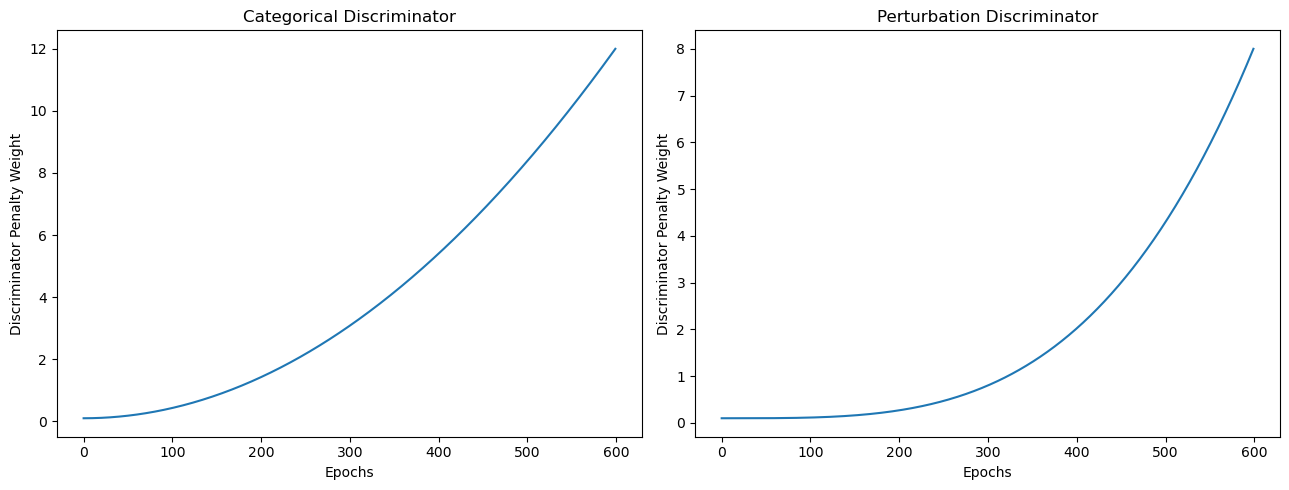

In [19]:
fig, ax = plt.subplots(ncols = 2, figsize = (13,5))
sns.lineplot(cat_discriminator_params['discriminator_penalty_weight'], ax = ax[0])
ax[0].set_title('Categorical Discriminator')

sns.lineplot(pert_discriminator_params['discriminator_penalty_weight'], ax = ax[1])
ax[1].set_title('Perturbation Discriminator')

for i in range(2):
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Discriminator Penalty Weight')
    
fig.tight_layout();

# Build model and trainer

In [202]:
# input stimulation
X_in = pd.get_dummies(tf_adata.obs.drug).astype(int)
X_in.drop(columns = 'DMSO_TF', inplace = True) # all 0s

In [203]:
mod = SignalingModel(
    net = sn_ppis,
    X_in = X_in,
    y_out = tf_adata.to_df().copy(), 
    expr = expr, 
    covariates = tf_adata.obs.copy(),
    categorical_covariate_keys = ['cell_line'],
    projection_amplitude_in = projection_amplitude_in, 
    projection_amplitude_out = projection_amplitude_out,
    weight_label = weight_label, source_label = source_label, target_label = target_label,
    bionet_params = bionet_params, 
    dtype = torch.float32, device = device, seed = mod_seed)

mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius


In [204]:
%%time
trainer = TrainSC(
    mod = mod,
    prediction_optimizer = torch.optim.Adam,
    prediction_loss_fn = prediction_loss_fn, 
    per_condition_loss = per_condition_loss,
    n_adversarial_start = n_adversarial_start, 
    n_discriminator_train = n_discriminator_train,
    gradient_ascent = True,
    cat_discriminator_params = cat_discriminator_params,
    pert_discriminator_params = pert_discriminator_params,
    vae_params = vae_params,
    hyper_params = training_params,
    train_split = {'train': train_cells, 'test': test_cells, 'validation': None}, 
    train_seed = mod_seed, 
    track_test = True,
    track_validation = False, 
    n_eval_cells = np.nan, 
    n_eval_bootstrap = np.nan
)

CPU times: user 31.9 s, sys: 1.26 s, total: 33.2 s
Wall time: 32.6 s


# Start

In [205]:
from scLEMBAS.model.train import *
self = trainer

In [206]:
start_time = time.time()
self.mod.signaling_network.implement_mask() # shouldn't be necessary bc called in signaling_network init

torch.autograd.set_detect_anomaly(True)

for e in trange(self.hyper_params['max_epochs']):
    self._no_vae = (self.n_adversarial_start > e) or (e % self.n_discriminator_train != 0)

    cur_lr = self.prediction_optimizer.param_groups[0]['lr']
    self.cat_discriminator['_cur_lr'] = self.cat_discriminator['optimizer'].param_groups[0]['lr']
    self.pert_discriminator['_cur_lr'] = self.pert_discriminator['optimizer'].param_groups[0]['lr']
    self.vae_learning['_cur_lr'] = self.vae_learning['optimizer'].param_groups[0]['lr']
    if self.hyper_params['max_epochs'] > self.n_adversarial_start:
        cur_catdisc_lambda = self.cat_discriminator['params']['discriminator_penalty_weight'][e]
        cur_pertdisc_lambda = self.pert_discriminator['params']['discriminator_penalty_weight'][e]
    else:
        cur_catdisc_lambda = torch.nan
        cur_pertdisc_lambda = torch.nan

    # iterate through batches
    if self.mod.seed:
        utils.set_seeds(self.mod.seed + e)
    break
for batch, (X_in_, y_out_, covariates_idx_, expr_) in enumerate(self.train_dataloader):
    break

  0%|                                           | 0/600 [00:00<?, ?it/s]


In [207]:
# set train mode or not (discriminator done below)
self.mod.train()
if self._no_vae:
    freeze_model(self.mod.signaling_network.vae)
else:
    unfreeze_model(self.mod.signaling_network.vae)


self.prediction_optimizer.zero_grad()
self.cat_discriminator['optimizer'].zero_grad()
self.pert_discriminator['optimizer'].zero_grad()
self.vae_learning['optimizer'].zero_grad()

X_in_, y_out_, covariates_idx_, expr_ = X_in_.to(self.mod.device), y_out_.to(self.mod.device), covariates_idx_.to(self.mod.device), expr_.to(self.mod.device)

######################## Forward Pass ########################
X_full = self.mod.input_layer(X_in_) # transform to full network with ligand input concentrations

# add noise to ninput
utils.set_seeds(self.mod.seed + self.mod._gradient_seed_counter)
network_noise = torch.randn(X_full.shape, device = X_full.device)
noise_scale_factor = self.hyper_params['network_noise_scale'] * (cur_lr/self.lr_scheduler.max_lr)
noise_scale_factor = max(noise_scale_factor, self.hyper_params['min_network_noise'])
X_full = X_full + (noise_scale_factor * network_noise) # randomly add noise to signaling network input, makes model more robust                Y_full, bias_terms = self.mod.signaling_network(X_full = X_full, 

# NEW
if self.n_adversarial_start <= e:
    Y_full, bias_terms = self.mod.signaling_network(X_full = X_full, 
                                                    covariates_idx = covariates_idx_, 
                                                    expr = expr_) # train signaling network weights
    bias_global, bias_mu, bias_log_sigma_squared = bias_terms
else:
    Y_full, _ = self.mod.signaling_network.forward_novar(X_full = X_full, 
                                                    covariates_idx = covariates_idx_, 
                                                    expr = expr_) # train signaling network weights

Y_hat = self.mod.output_layer(Y_full)

In [208]:
if self.n_adversarial_start <= e:
    unfreeze_model(model = self.pert_discriminator['discriminator'])
    for discriminator in self.cat_discriminator['discriminators'].values():
        unfreeze_model(model = discriminator)

    ######################## Categorical DISCRIMINATOR ########################
    # discriminator prediction and loss
    cat_discriminator_loss_accuracy = torch.tensor(0, device = self.mod.device, dtype = self.mod.dtype)
    for cat_group_idx, (cat, discriminator) in enumerate(self.cat_discriminator['discriminators'].items()):
        bias_global_prediction = discriminator(bias_global.detach()) # predicted logits
        # if don't use retain_graph = True, then use bias_global.detach() here

        target = covariates_idx_[:, cat_group_idx]
        if discriminator.n_labels == 2:
            target = target.to(self.mod.dtype).unsqueeze(1)

        cat_discriminator_loss_accuracy += discriminator.loss_fn(bias_global_prediction, target)   

    # discriminator regularization
    cat_discriminator_reg = torch.tensor(0, device = self.mod.device, dtype = self.mod.dtype)
    for discriminator in self.cat_discriminator['discriminators'].values():
        cat_discriminator_reg += discriminator.L2_reg(self.cat_discriminator['params']['discriminator_lambda_L2'])
    cat_discriminator_loss = cat_discriminator_loss_accuracy + cat_discriminator_reg

    # discriminator optimization
    # NOTE: discriminator is optimized prior to adverserial training (and loss re-calculated)
    cat_discriminator_loss.backward() # if bias global is not detached, need to set retain_graph = True here
    cat_grad_l2s = np.array([self.get_global_l2_norm(mod_discriminator) for mod_discriminator in self.cat_discriminator['discriminators'].values()])
    self.cat_discriminator['optimizer'].step()

    # freeze discriminator (to prevent updating discriminator gradients when calling discriminator while 
    # training generator adverserially below)
    for discriminator in self.cat_discriminator['discriminators'].values():
        freeze_model(model = discriminator)

In [209]:
self.pert_discriminator['discriminator'].n_labels != 2

True

In [210]:
target = X_in_.argmax(dim=1)

1

In [ ]:
bias_global_prediction = self.pert_discriminator['discriminator'](bias_global.detach()) # predicted logits

if self.pert_discriminator['discriminator'].n_labels != 2:
    target = X_in_.argmax(dim=1)
    # differentiate between rows with no perturbation and rows with perturbation at column 1 (index 0)
    no_pert = X_in_.sum(dim=1) == 0  
    target[no_pert] = self.pert_discriminator['discriminator'].n_labels - 1 # -1 for indexing
else:
    target = X_in_#.long().reshape(-1)


pert_discriminator_loss_accuracy = self.pert_discriminator['discriminator'].loss_fn(bias_global_prediction, target)   

# discriminator regularization
pert_discriminator_reg = self.pert_discriminator['discriminator'].L2_reg(self.pert_discriminator['params']['discriminator_lambda_L2'])
pert_discriminator_loss = pert_discriminator_loss_accuracy + pert_discriminator_reg

# discriminator optimization
pert_discriminator_loss.backward() # if bias global is not detached, need to set retain_graph = True here
pert_grad_l2 = self.get_global_l2_norm(self.pert_discriminator['discriminator']) # tracking
self.pert_discriminator['optimizer'].step()

# freeze discriminator
freeze_model(model = self.pert_discriminator['discriminator'])

In [179]:





    # NOTE: 
    # a good adverserial check here is to see if the vae (and all self.mod) param gradients are still 0, 
    # as the backward pass for prediction has not yet been called; when using the retain_graph = True
    # and not calling bias_global.detach() above, the gradients from calculating the discriminator loss
    # on bias global were leaking into the generator portion

    ######################## Perturbation DISCRIMINATOR ########################
    # same implementation as categorical discriminator currently
    # discriminator prediction and loss

else:
    cat_discriminator_loss = torch.tensor(0.0)
    pert_discriminator_loss = torch.tensor(0.0)
    cat_discriminator_loss_accuracy = torch.tensor(0.0)
    pert_discriminator_loss_accuracy = torch.tensor(0.0)
    cat_discriminator_reg = torch.tensor(0.0)
    pert_discriminator_reg = torch.tensor(0.0)
    cat_grad_l2s = np.array([0]*len(self.cat_discriminator['discriminators']))
    pert_grad_l2 = 0


######################## LEMBAS and generator ########################
# reconstruction loss
prediction_loss = self.compute_loss(y_out_, Y_hat, X_in_, covariates_idx_)

# lembas regularization
sign_reg = self.mod.signaling_network.sign_regularization(lambda_L1 = self.hyper_params['moa_lambda_L1']) # incorrect MoA
#             ligand_reg = self.mod.ligand_regularization(lambda_L2 = self.hyper_params['ligand_lambda_L2']) # ligand biases
stability_loss, spectral_radius = self.mod.signaling_network.get_SS_loss(Y_full = Y_full.detach(), spectral_loss_factor = self.hyper_params['spectral_loss_factor'],
                                                                    subset_n = self.hyper_params['subset_n_spectral'], n_probes = self.hyper_params['n_probes_spectral'], 
                                                                    power_steps = self.hyper_params['power_steps_spectral'])
uniform_reg = self.mod.uniform_regularization(lambda_L2 = self.hyper_params['uniform_lambda_L2']*cur_lr, Y_full = Y_full, 
                                        target_min = 0, target_max = self.hyper_params['uniform_max']) # uniform distribution

input_param_reg, sn_param_reg, output_param_reg = self.mod.L2_reg(input_lambda_L2=self.hyper_params['input_lambda_L2'],
                            bn_weights_lambda_L2=self.hyper_params['bn_weights_lambda_L2'], 
                            global_bias_lambda_L2=self.hyper_params['global_bias_lambda_L2'], 
                            bias_global = torch.tensor(0) if self._no_vae else bias_global,
                            cat_bias_lambda_L2=self.hyper_params['cat_bias_lambda_L2'],
                            output_weights_lambda_L2=self.hyper_params['output_weights_lambda_L2'],
                            output_bias_lambda_L2=self.hyper_params['output_bias_lambda_L2'])
sn_bias_l1_reg = self.mod.signaling_network.L1_reg_bias(bias_global = torch.tensor(0) if self._no_vae else bias_global, 
                                                        global_bias_lambda_L1 = self.hyper_params['global_bias_lambda_L1'], 
                                                        cat_bias_lambda_L1 = self.hyper_params['cat_bias_lambda_L1'])
#                 from collections import OrderedDict
#                 sn_cat_bias_orthogonality_reg = OrderedDict({'cat_bias_orthogonality_loss': 0})
sn_cat_bias_orthogonality_reg = self.mod.signaling_network.cat_orthogonality_regularization(covariates_idx = covariates_idx_,
                                                                                            X_in = X_in_,
                                                                                            regularization_scaler = self.hyper_params['cat_bias_orthogonality_scaler'])
sn_param_reg = {**sn_param_reg, **sn_bias_l1_reg, **sn_cat_bias_orthogonality_reg}
param_reg = input_param_reg + sum(sn_param_reg.values()) + sum(output_param_reg.values())
vae_reg = torch.tensor(0.0)
if not self._no_vae:
    vae_reg = self.mod.signaling_network.vae.L2_reg(lambda_L2=self.vae_learning['params']['lambda_l2']) 
param_reg += vae_reg

# NOTE: KL divergence is scaled to match loss magnitudes; no bias regularization given KL regularization
# can use MMD in the future if KL unstable

# for adj matrix 
if self.hyper_params['adj_scaling_KL'] == 0:
    kl_divergence_adj = torch.tensor(0.0, device=self.mod.device, dtype=self.mod.dtype)
else:
    unmasked_weights = self.mod.signaling_network.weights[~self.mod.signaling_network.mask]
    kl_divergence_adj = self.hyper_params['adj_scaling_KL'] *kl_divergence_normal(empirical_values = unmasked_weights, 
                                                mu=self.hyper_params['adj_prior_mu'], 
                                                sigma=self.hyper_params['adj_prior_sigma'], 
                                                eps=1e-8)

kl_divergence_gb = torch.tensor(0.0)
if not self._no_vae:
    # for global bias
    kl_divergence_gb = self.mod.signaling_network.vae.KL_divergence(z_mu = bias_mu, 
                                                                z_log_sigma_squared = bias_log_sigma_squared, 
                                                                scaling_factor = self.vae_learning['params']['scaling_KL'], 
                                                                prior_mu = self.vae_learning['params']['prior_mu'], 
                                                                prior_sigma = self.vae_learning['params']['prior_sigma'])
tot_pred_loss = prediction_loss + sign_reg + param_reg + stability_loss + uniform_reg + kl_divergence_gb + kl_divergence_adj

pert_adverserial_loss, cat_adverserial_loss = torch.tensor(0.0), torch.tensor(0.0)
if not self._no_vae:

    # adverserial portion -- same as discriminator, but recalculating on trained model
    # adverserial portion -- same as discriminator, but recalculating on trained model
    # categorical adversary
    cat_adverserial_loss = torch.tensor(0, device = self.mod.device, dtype = self.mod.dtype)
    for cat_group_idx, (covariate_cat, discriminator) in enumerate(self.cat_discriminator['discriminators'].items()):
        bias_global_prediction = discriminator(bias_global) 

        target = covariates_idx_[:, cat_group_idx]
        if discriminator.n_labels == 2:
            target = target.to(self.mod.dtype).unsqueeze(1) if not self.gradient_ascent else 1 - target.to(self.mod.dtype).unsqueeze(1)
        else:
            if self.gradient_ascent:
                utils.set_seeds(self.mod.seed + e + batch)
                target = self.flip_labels_proportional(true_labels = target, 
                                                            classes = self.cat_class_probs[covariate_cat]['classes'], 
                                                            probs = self.cat_class_probs[covariate_cat]['probs'], 
                                                            n_labels = discriminator.n_labels)

        cat_adverserial_loss += discriminator.loss_fn(bias_global_prediction, target)  

    # perturbation adversary
    bias_global_prediction = self.pert_discriminator['discriminator'](bias_global) 
    if self.pert_discriminator['discriminator'].n_labels == 2:
        target = X_in_ if not self.gradient_ascent else 1 - X_in_
    else:
        target = X_in_.argmax(dim=1)
        no_pert = X_in_.sum(dim=1) == 0  
        target[no_pert] = self.pert_discriminator['discriminator'].n_labels - 1

        if self.gradient_ascent:
            utils.set_seeds(self.mod.seed + e + batch)
            target = self.flip_labels_proportional(true_labels = target, 
                                                        classes = self.pert_class_probs['classes'], 
                                                        probs = self.pert_class_probs['probs'], 
                                                        n_labels = self.pert_discriminator['discriminator'].n_labels)
    pert_adverserial_loss = self.pert_discriminator['discriminator'].loss_fn(bias_global_prediction, target) 

    if self.gradient_ascent:
        # goal is worse accuracy of discriminator
        # without label flipping trick, we are maximizing the loss of the actual labels
        # conversely, with label flipping, we are minimizing the loss with flipped labels
        pert_adverserial_loss = -pert_adverserial_loss
        cat_adverserial_loss = -cat_adverserial_loss

tot_pred_loss = tot_pred_loss - (cur_catdisc_lambda*cat_adverserial_loss) - (cur_pertdisc_lambda*pert_adverserial_loss)


# model gradient
tot_pred_loss.backward()

# tracking
vae_grad_l2 = 0
if self.n_adversarial_start <= e:
    vae_grad_l2 = self.get_global_l2_norm(self.mod.signaling_network.vae) 

self.add_gradient_noise(cur_lr, e, batch)
#                 self.mod.add_gradient_noise(noise_level = self.hyper_params['gradient_noise_scale'])
self.prediction_optimizer.step()
if not self._no_vae:
    self.vae_learning['optimizer'].step()
self.mod.signaling_network.implement_mask() # moved out of forward pass to ensure after last backpass these are 0

tensor(2.2687e-06, device='cuda:0', grad_fn=<MulBackward0>)

# To do:
- does the X_initialization follow the categorical order?


In [183]:
tf_adata.obs.drug.cat.categories

Index(['Afatinib', 'Almonertinib (mesylate)', 'Bexarotene', 'Binimetinib',
       'Brimonidine', 'Cabozantinib (S-malate)', 'Clonidine (hydrochloride)',
       'Crizotinib (hydrochloride)', 'DMSO_TF', 'Dabrafenib', 'Filgotinib',
       'Gefitinib', 'Irinotecan (hydrochloride)', 'Naproxen',
       'Neratinib (maleate)', 'Norepinephrine (hydrochloride)', 'Piroxicam',
       'Rapamycin', 'Regorafenib', 'Retinoic acid', 'Rucaparib (phosphate)',
       'Sodium Salicylate', 'Temsirolimus', 'Tirabrutinib (hydrochloride)',
       'Tofacitinib', 'Tofacitinib (citrate)', 'Trametinib', 'Tucidinostat',
       'Vilanterol'],
      dtype='object')

In [192]:
ctrl_cells = X_in[X_in['DMSO_TF'] == 1].index.tolist()

In [198]:
ctrl_cells_2 = X_in[X_in.sum(axis = 1) == 0].index.tolist()

In [199]:
ctrl_cells == ctrl_cells_2

True